<div align="center">
  <h1>Notebook 03: Predictive Modeling with XGBoost</h1>
  <h3>Biotech Project: Genomic Classification for Personalized Medicine</h3>
  <h3>Proyecto Biotecnológico: Clasificación Genómica para Medicina Personalizada</h3>
</div>

---

## 📌 Executive Summary / Resumen Ejecutivo

**[EN]** Statistical significance confirms that biological differences exist, but predictive modeling is required to translate those differences into actionable clinical diagnostics. In this notebook, we train an Extreme Gradient Boosting (`XGBoost`) classifier on our mathematically reduced genomic feature space. The goal is to predict whether a tissue sample is pathological (malignant) or healthy (benign) with high accuracy, precision, and recall. 

**[ES]** La significancia estadística confirma que existen diferencias biológicas, pero se requiere modelado predictivo para traducir esas diferencias en diagnósticos clínicos procesables. En este notebook, entrenamos un clasificador de Extreme Gradient Boosting (`XGBoost`) sobre nuestro espacio de características genómicas matemáticamente reducido. El objetivo es predecir si una muestra de tejido es patológica (maligna) o sana (benigna) con alta exactitud, precisión y exhaustividad (recall).

---

## 🎯 Objectives / Objetivos
1. **[EN]** Partition the dataset into training and testing cohorts to ensure objective evaluation. / **[ES]** Particionar el conjunto de datos en cohortes de entrenamiento y prueba para garantizar una evaluación objetiva.
2. **[EN]** Train an XGBoost model, an industry-standard algorithm for tabular data. / **[ES]** Entrenar un modelo XGBoost, un algoritmo estándar en la industria para datos tabulares.
3. **[EN]** Evaluate model performance using a Confusion Matrix and the ROC-AUC score. / **[ES]** Evaluar el rendimiento del modelo utilizando una Matriz de Confusión y el puntaje ROC-AUC.
4. **[EN]** Export predictions for the interactive Dashboard. / **[ES]** Exportar las predicciones para el Dashboard interactivo.

In [3]:
# ==============================================================================
# 1. Environment Configuration & Library Imports
# ==============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Core Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    accuracy_score
)
import xgboost as xgb

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Path Management
PROJECT_ROOT = Path.cwd().parent
DIR_DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DIR_RESULTS_FIGS = PROJECT_ROOT / "results" / "figures"
DIR_RESULTS_DASH = PROJECT_ROOT / "results" / "dashboard_exports"

# ==============================================================================
# 2. Load Processed Data
# ==============================================================================
def load_processed_data() -> pd.DataFrame:
    """Loads the PCA-transformed dataset from Notebook 01."""
    input_path = DIR_DATA_PROCESSED / "genomics_pca_cleaned.csv"
    df = pd.read_csv(input_path)
    print(f"[+] Loaded processed dataset: {df.shape[0]} patients, {df.shape[1]-1} Features.")
    return df

df_model = load_processed_data()

[+] Loaded processed dataset: 569 patients, 10 Features.


### Model Training / Entrenamiento del Modelo
**[EN]** We utilize an 80/20 train-test split. The `XGBClassifier` is parameterized to handle potential class imbalances and prevent overfitting.
**[ES]** Utilizamos una división de entrenamiento y prueba de 80/20. El `XGBClassifier` está parametrizado para manejar posibles desequilibrios de clases y prevenir el sobreajuste.

In [6]:
# ==============================================================================
# 3. Model Pipeline & Training
# ==============================================================================
# Separate features and target
X = df_model.drop(columns=['target_pathology'])
y = df_model['target_pathology']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"[+] Training cohort size: {X_train.shape[0]} patients")
print(f"[+] Testing cohort size: {X_test.shape[0]} patients")

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
print("[+] Training XGBoost model...")
xgb_model.fit(X_train, y_train)

# Generate predictions and probabilities for the test set
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Quick overview of baseline accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Training Complete. Test Accuracy: {acc:.4f}")

[+] Training cohort size: 455 patients
[+] Testing cohort size: 114 patients
[+] Training XGBoost model...
✅ Model Training Complete. Test Accuracy: 0.9474


### Model Evaluation / Evaluación del Modelo
**[EN]** In clinical diagnostics, accuracy alone is insufficient. We must minimize False Negatives (telling a sick patient they are healthy). We evaluate this using the Confusion Matrix and ROC Curve.
**[ES]** En el diagnóstico clínico, la exactitud por sí sola es insuficiente. Debemos minimizar los Falsos Negativos (decirle a un paciente enfermo que está sano). Evaluamos esto utilizando la Matriz de Confusión y la Curva ROC.

🏥 CLINICAL CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Pathological (0)       0.93      0.93      0.93        42
     Healthy (1)       0.96      0.96      0.96        72

        accuracy                           0.95       114
       macro avg       0.94      0.94      0.94       114
    weighted avg       0.95      0.95      0.95       114

[+] Exported evaluation metrics to: model_evaluation_metrics.png


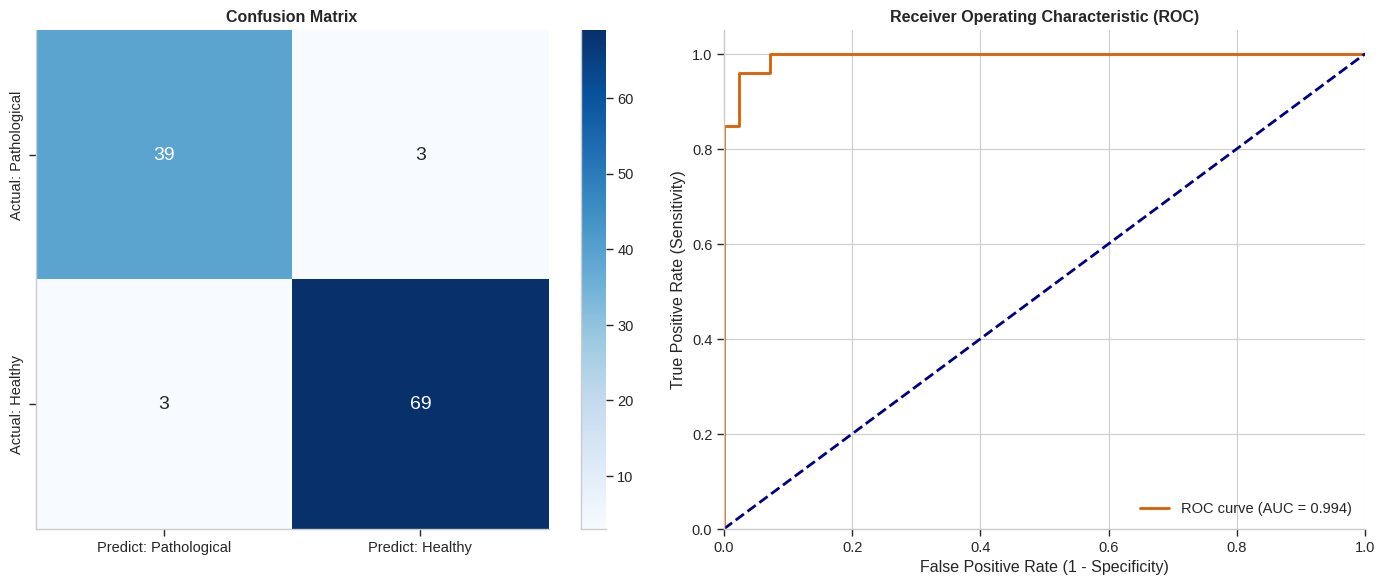

In [8]:
# ==============================================================================
# 4. Evaluation Metrics & Visualization
# ==============================================================================
def evaluate_model_performance(y_test, y_pred, y_prob):
    """
    Prints clinical classification metrics and plots Confusion Matrix & ROC Curve.
    """
    print("=" * 60)
    print("🏥 CLINICAL CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=['Pathological (0)', 'Healthy (1)']))
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Predict: Pathological', 'Predict: Healthy'],
                yticklabels=['Actual: Pathological', 'Actual: Healthy'],
                annot_kws={"size": 14})
    axes[0].set_title('Confusion Matrix', weight='bold')
    
    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='#d95f02', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Sensitivity)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', weight='bold')
    axes[1].legend(loc="lower right")
    
    sns.despine()
    plt.tight_layout()
    
    # Save artifacts
    output_path = DIR_RESULTS_FIGS / "model_evaluation_metrics.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[+] Exported evaluation metrics to: {output_path.name}")
    plt.show()

evaluate_model_performance(y_test, y_pred, y_prob)

In [10]:
# ==============================================================================
# 5. Dashboard Data Export
# ==============================================================================
def export_predictions_for_dashboard(X_test, y_test, y_pred, y_prob):
    """
    Compiles the test set features, actual targets, and model predictions 
    into a clean CSV for Streamlit/Tableau visualization.
    """
    # Create a copy of the test features
    df_export = X_test.copy()
    
    # Append truth, predictions, and probabilities
    df_export['Actual_Diagnosis'] = y_test.values
    df_export['Model_Prediction'] = y_pred
    df_export['Prediction_Probability_Healthy'] = y_prob
    df_export['Prediction_Probability_Pathological'] = 1 - y_prob
    
    # Determine if the model was correct (useful for filtering in BI tools)
    df_export['Prediction_Correct'] = df_export['Actual_Diagnosis'] == df_export['Model_Prediction']
    
    # Export
    output_path = DIR_RESULTS_DASH / "model_predictions_summary.csv"
    df_export.to_csv(output_path, index=False)
    print(f"💾 SUCCESS: Model predictions saved for Dashboard at: {output_path.name}")

export_predictions_for_dashboard(X_test, y_test, y_pred, y_prob)

💾 SUCCESS: Model predictions saved for Dashboard at: model_predictions_summary.csv
